In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from tqdm.notebook import tqdm
import seaborn as sns
from datetime import datetime
import utils.utils as utils
import pandas as pd

from v1_evaluation import evaluate_frechet_gesture_distance
from v1_training_loop import resume_training_from_checkpoint

In [60]:
# Function to load a model from checkpoint
def load_model_from_checkpoint(checkpoint_path, device):
    # Create dummy objects needed for the resume function
    dummy_optimizer = torch.optim.AdamW(torch.nn.Linear(1, 1).parameters())
    train_loss_rec = {'loss':([],[]), 'reconstruction_loss':([],[]), 
                      'encoded_latent_space_loss':([],[]), 'variance_loss':([],[]), 
                      'velocity_loss':([],[]), 'acceleration_loss':([],[]),
                      'jerk_loss':([],[]), 'epoch_loss':([],[])}
    val_loss_rec = {'loss':([],[]), 'reconstruction_loss':([],[]),
                   'encoded_latent_space_loss':([],[]), 'variance_loss':([],[]), 
                   'velocity_loss':([],[]), 'acceleration_loss':([],[]),
                   'jerk_loss':([],[])}
    frechet_distance_rec = {'encoded': [], 'raw': []}
    
    model, _ = resume_training_from_checkpoint(
        checkpoint_path=checkpoint_path,
        optimizer=dummy_optimizer,
        train_loss_rec=train_loss_rec,
        val_loss_rec=val_loss_rec,
        frechet_distance_rec=frechet_distance_rec,
        device=device
    )
    return model

def calculate_fgd_score_and_bootstrap(model, val_loader, device, num_iterations=100, 
                                 evaluation_length=30, samples_per_iteration=8192, bootstrap_samples=1024):
    """
    Calculate FGD scores multiple times and return all results
    """
    model.eval()

    fgd_score, _, bootstrap_results = evaluate_frechet_gesture_distance(
        model=model,
        val_loader=val_loader,
        device=device,
        evaluation_length=evaluation_length,
        calculate_raw_frechet_distance=False,
        samples_per_iteration=samples_per_iteration,
        num_iterations=num_iterations,
        bootstrap_samples=bootstrap_samples
    )
    
    print(f"FGD Score: {fgd_score:.4f}")
    print(f"Bootstrap Results: {bootstrap_results}")

    return fgd_score, bootstrap_results

# Function to save results
def save_fgd_results(model_name, fgd_score, bootstrap_results, output_dir="fgd_results"):
    """
    Save FGD scores to a JSON file
    """
    os.makedirs(output_dir, exist_ok=True)
    
    results = {
        "model_name": model_name,
        "datetime": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "fgd_score": fgd_score,
        "bootstrap_results": bootstrap_results
        # "mean": float(np.mean(fgd_scores)),
        # "std": float(np.std(fgd_scores)),
        # "min": float(np.min(fgd_scores)),
        # "max": float(np.max(fgd_scores)),
        # "median": float(np.median(fgd_scores)),
        # "num_iterations": len(fgd_scores)
    }
    
    filename = f"{output_dir}/{model_name.replace('/', '_')}_fgd_results.json"
    with open(filename, 'w') as f:
        json.dump(results, f, indent=4)
    
    print(f"Results saved to {filename}")
    return filename

# Function to load all results for comparison
def load_all_fgd_results(results_dir="fgd_results"):
    """
    Load all FGD results from the directory
    """
    all_results = []
    for filename in os.listdir(results_dir):
        if filename.endswith("_fgd_results.json"):
            filepath = os.path.join(results_dir, filename)
            with open(filepath, 'r') as f:
                results = json.load(f)
                all_results.append(results)
    
    return all_results

# Function to plot FGD score histograms
def plot_fgd_histograms(results_list):
    """
    Plot histograms of FGD scores with color coding:
    - Sliding diffusion models: Green shades
    - Standard diffusion models: Red shades
    """
    plt.figure(figsize=(14, 10))
    
    # Separate models by type
    sliding_models = [r for r in results_list if "sliding" in r["model_name"].lower()]
    standard_models = [r for r in results_list if "sliding" not in r["model_name"].lower()]
    
    # Generate random green shades for sliding models
    green_shades = []
    for _ in range(max(1, len(sliding_models))):
        g = np.random.uniform(0.65, 0.8)  # Strong green component
        r = np.random.uniform(0, 0.3)     # Lower red component
        b = np.random.uniform(0, 0.3)     # Lower blue component
        green_shades.append((r, g, b))
    
    # Generate random red shades for standard models
    red_shades = []
    for _ in range(max(1, len(standard_models))):
        r = np.random.uniform(0.65, 0.8)   # Strong red component
        g = np.random.uniform(0, 0.3)     # Lower green component
        b = np.random.uniform(0, 0.3)     # Lower blue component
        red_shades.append((r, g, b))
    
    # Plot sliding diffusion models (greens)
    for i, results in enumerate(sliding_models):
        model_name = results["model_name"]
        fgd_scores = results["bootstrap_results"]["bootstrap_fgds"]
        mean_fgd = results["bootstrap_results"]["mean"]
        std_fgd = results["bootstrap_results"]["std"]
        true_fgd = results["fgd_score"]

        # Use the same color with alpha for edge color
        edge_color = green_shades[i % len(green_shades)]
        edge_rgba = (edge_color[0], edge_color[1], edge_color[2], 0.2)  # Set edge alpha to 0.5
        
        sns.histplot(fgd_scores, kde=False, 
                    label=f"{model_name} (μ={mean_fgd:.4f}, σ={std_fgd:.4f})",
                    color=green_shades[i % len(green_shades)], edgecolor=edge_rgba, alpha=0.1)
        
        plt.axvline(true_fgd, color=green_shades[i % len(green_shades)], 
                   linestyle='--', linewidth=3,
                   label=f"{model_name} True FGD: {true_fgd:.2f}")
    
    # Plot standard diffusion models (reds)
    for i, results in enumerate(standard_models):
        model_name = results["model_name"]
        fgd_scores = results["bootstrap_results"]["bootstrap_fgds"]
        mean_fgd = results["bootstrap_results"]["mean"]
        std_fgd = results["bootstrap_results"]["std"]
        true_fgd = results["fgd_score"]
        
         # Use the same color with alpha for edge color
        edge_color = red_shades[i % len(red_shades)]
        edge_rgba = (edge_color[0], edge_color[1], edge_color[2], 0.2)  # Set edge alpha to 0.5

        sns.histplot(fgd_scores, kde=False, 
                    label=f"{model_name} (μ={mean_fgd:.4f}, σ={std_fgd:.4f})",
                    color=red_shades[i % len(red_shades)], edgecolor=edge_rgba, alpha=0.1)
        
        plt.axvline(true_fgd, color=red_shades[i % len(red_shades)], 
                   linestyle='--', linewidth=3,
                   label=f"{model_name} True FGD: {true_fgd:.2f}")
    
    # Add title and labels
    plt.suptitle("FGD Score Distribution Comparison", fontsize=16)
    plt.title("Color coding: Sliding Diffusion (Green), Standard Diffusion (Red)", 
              fontsize=12, pad=10)
    plt.xlabel("FGD Score", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Place legend properly
    plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)
    
    # Adjust layout and save figure
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)  # Make room for the legend
    plt.savefig("fgd_comparison_histogram.png", dpi=300, bbox_inches="tight", pad_inches=0.5)
    plt.show()
    
    # Create a summary table
    summary_data = []
    for results in results_list:
        summary_data.append({
            "Model": results["model_name"],
            "Type": "Sliding Diffusion" if "sliding" in results["model_name"].lower() else "Standard Diffusion",
            "Mean FGD": results["bootstrap_results"]["mean"],
            "Std Dev": results["bootstrap_results"]["std"],
            "95% CI Low": results["bootstrap_results"]["ci_low"],
            "95% CI High": results["bootstrap_results"]["ci_high"],
            "True FGD": results["fgd_score"],
            "# Samples": len(results["bootstrap_results"]["bootstrap_fgds"])
        })
    
    summary_df = pd.DataFrame(summary_data)
    display(summary_df.sort_values(by="Mean FGD"))

In [63]:
from torch.utils.data import DataLoader

from dataset.dataset import GPUDataset

device = utils.get_device()
print(f"Using device: {device}")

# Configuration - set these values
checkpoint_path = "models/normal/normal_seed_8__hiiovd2k_epoch_701.pth"
model_name = "normal_seed_8"  # Use a descriptive name
num_iterations = 100  # Number of FGD calculations to perform

# Cell to run for a single model evaluation
# Load model
model = load_model_from_checkpoint(checkpoint_path, device)

# Get validation data loader
val_loader = DataLoader(
    GPUDataset(
        consolidated_file = "dataset/genea2023_dataset/val/main-agent/consolidated.npz",
        seq_length = 70,
        seed_length = 8,
        batch_size = 64,
        epoch_length = 30,
        loading_encoded_data = False,
        include_vel_acc_features = False,
        device = device
    ),
    batch_size = 1,
    num_workers = 0,
    pin_memory = False
)

# Calculate FGD scores
fgd_score, bootstrap_results = calculate_fgd_score_and_bootstrap(
    model=model,
    val_loader=val_loader,
    device=device,
    num_iterations=num_iterations,
    evaluation_length=30,
    samples_per_iteration=8192,
    bootstrap_samples=1024
)

# Save results
save_fgd_results(model_name, fgd_score, bootstrap_results)

Using device: cuda
Could not load optimizer state. Optimizer will be initialized from scratch.
Initializing GPU-resident dataset on cuda
Loading data from dataset/genea2023_dataset/val/main-agent/consolidated.npz directly to GPU...
Data loaded to GPU. Gesture shape: torch.Size([75600, 345]), Audio shape: torch.Size([75600, 37])
Found 72443 valid starting points for windows
Dataset initialization complete!
Processing iteration 1/100
Processing iteration 2/100
Processing iteration 3/100
Processing iteration 4/100
Processing iteration 5/100
Processing iteration 6/100
Processing iteration 7/100
Processing iteration 8/100
Processing iteration 9/100
Processing iteration 10/100
Processing iteration 11/100
Processing iteration 12/100
Processing iteration 13/100
Processing iteration 14/100
Processing iteration 15/100
Processing iteration 16/100
Processing iteration 17/100
Processing iteration 18/100
Processing iteration 19/100
Processing iteration 20/100
Processing iteration 21/100
Processing i

: 

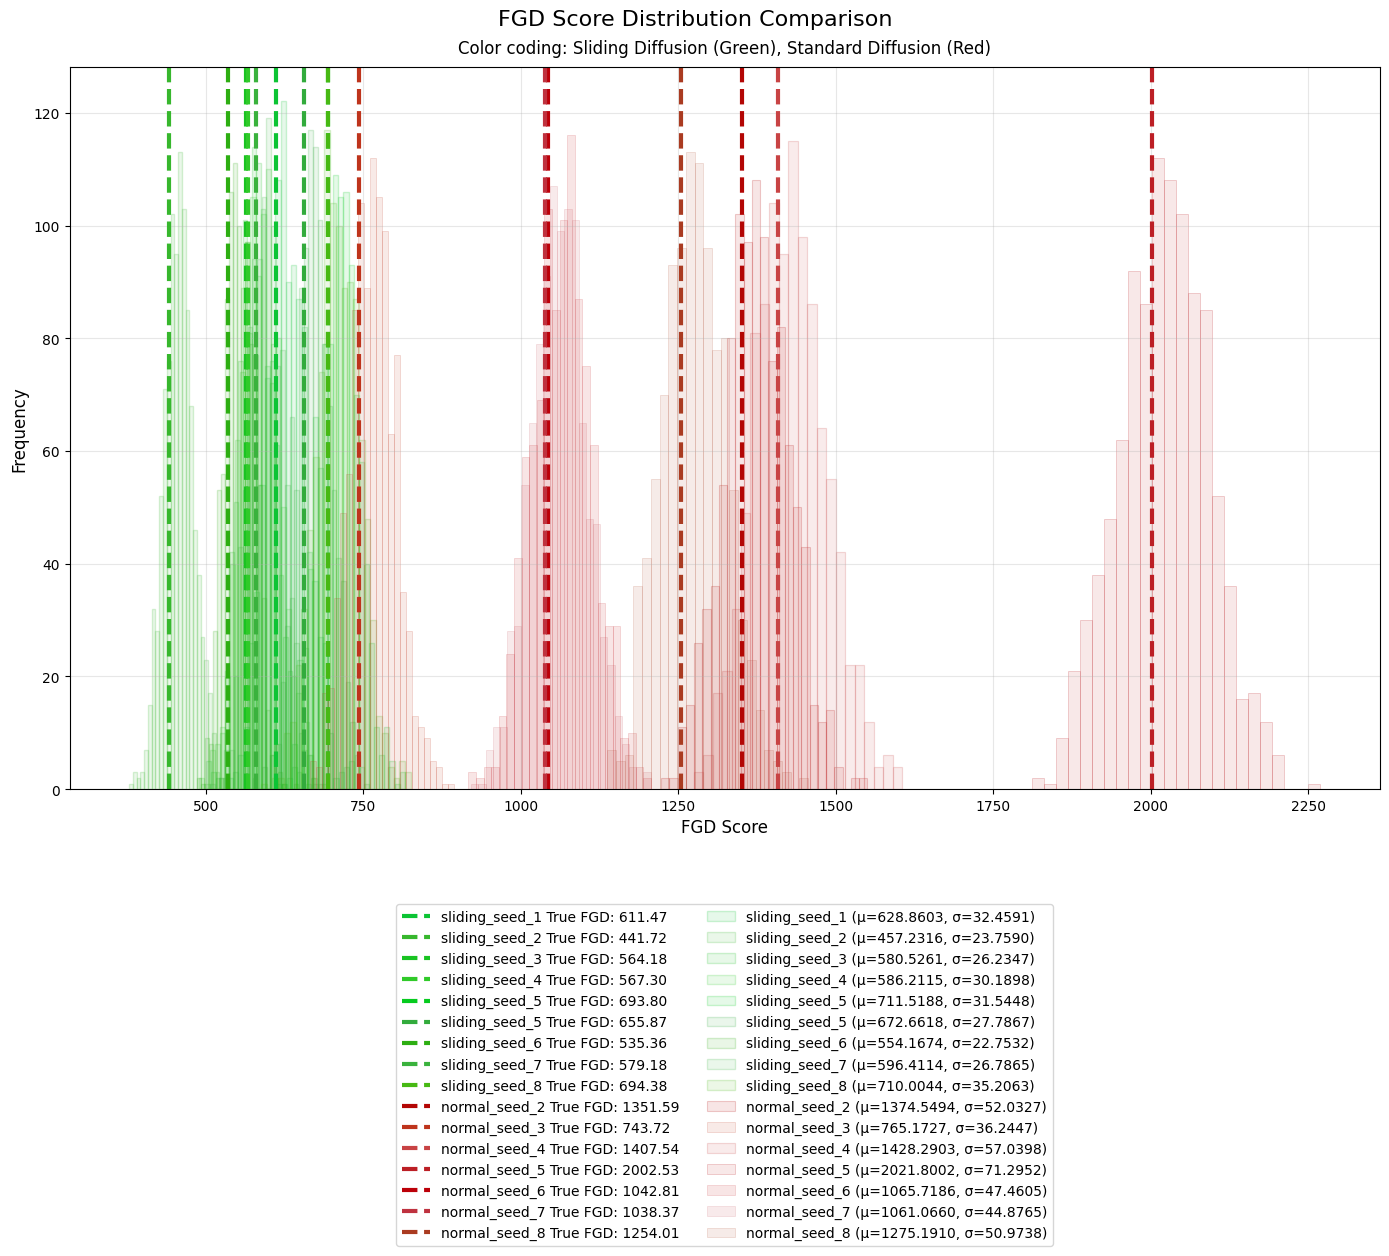

,Model,Type,Mean FGD,Std Dev,95% CI Low,95% CI High,True FGD,# Samples
8,sliding_seed_2,Sliding Diffusion,457.231623,23.759046,413.694142,505.644063,441.721697,1024
13,sliding_seed_6,Sliding Diffusion,554.167433,22.753207,513.263552,597.140428,535.361813,1024
9,sliding_seed_3,Sliding Diffusion,580.526140,26.234734,533.032115,631.572403,564.178377,1024
10,sliding_seed_4,Sliding Diffusion,586.211455,30.189754,528.140888,645.935074,567.300481,1024
14,sliding_seed_7,Sliding Diffusion,596.411380,26.786480,547.741279,649.864337,579.184753,1024
7,sliding_seed_1,Sliding Diffusion,628.860277,32.459116,570.571069,693.610708,611.471999,1024
12,sliding_seed_5,Sliding Diffusion,672.661803,27.786708,621.191291,728.086581,655.870980,1024
15,sliding_seed_8,Sliding Diffusion,710.004413,35.206303,639.975324,778.542671,694.384810,1024
11,sliding_seed_5,Sliding Diffusion,711.518756,31.544767,651.311112,774.905439,693.797895,1024
1,normal_seed_3,Standard Diffusion,765.172661,36.244722,694.358810,842.332037,743.720724,1024


In [62]:
# Cell to run for comparing all evaluated models
# Load all results and compare
all_results = load_all_fgd_results()
plot_fgd_histograms(all_results)